In [19]:
import motion_models
from data_handling import get_file_data_for_kf


In [20]:
# filename = './data/robot_data_0_-20_26_02_26_23_40_54.pkl'
filename = './data/robot_data_0_0_27_02_26_18_30_11.pkl'
# filename = './data/robot_data_0_0_27_02_26_22_23_57.pkl'

ekf_data = get_file_data_for_kf(filename)

time_list = [t for t, _, _, _ in ekf_data]
encoder_count_list = [r.encoder_counts for _, _, r, _ in ekf_data]
steering_angle_list = [r.steering for _, _, r, _ in ekf_data]
x_cam_list = [cam[0] if cam is not None else None for _, _, _, cam in ekf_data]
y_cam_list = [cam[1] if cam is not None else None for _, _, _, cam in ekf_data]
theta_cam_list = [cam[2] if cam is not None else None for _, _, _, cam in ekf_data]


In [21]:
import importlib
importlib.reload(motion_models)

motion_model = motion_models.MyMotionModel([x_cam_list[0], y_cam_list[0], theta_cam_list[0]], encoder_count_list[0])
x_model, y_model, theta_model = motion_model.traj_propagation(time_list, encoder_count_list, steering_angle_list)


In [22]:
# Run EKF on data and get EKF estimates
import numpy as np
import importlib
import motion_models
import extended_kalman_filter
importlib.reload(motion_models)
importlib.reload(extended_kalman_filter)

from extended_kalman_filter import ExtendedKalmanFilter
from robot_python_code import parameters


x_0 = [x_cam_list[0], y_cam_list[0], theta_cam_list[0]]
Sigma_0 = parameters.I3
encoder_counts_0 = encoder_count_list[0]
extended_kalman_filter_obj = ExtendedKalmanFilter(x_0, Sigma_0, encoder_counts_0)

x_ekf_list = []
y_ekf_list = []
theta_ekf_list = []
cov_list = []  # store full 3x3 covariance at each step

for t in range(1, len(encoder_count_list)):
    row = ekf_data[t]
    delta_t = ekf_data[t][0] - ekf_data[t-1][0] # time step size
    u_t = np.array([encoder_count_list[t], steering_angle_list[t]]) # robot_sensor_signal

    # Pass None when camera data is missing, not np.array([None, None, None])
    cam = row[3]
    z_t = np.array(cam) if cam is not None else None

    # Run the EKF for a time step
    extended_kalman_filter_obj.update(u_t, z_t, delta_t)

    x_ekf_list.append(extended_kalman_filter_obj.state_mean[0])
    y_ekf_list.append(extended_kalman_filter_obj.state_mean[1])
    theta_ekf_list.append(extended_kalman_filter_obj.state_mean[2])
    cov_list.append(np.array(extended_kalman_filter_obj.state_covariance))

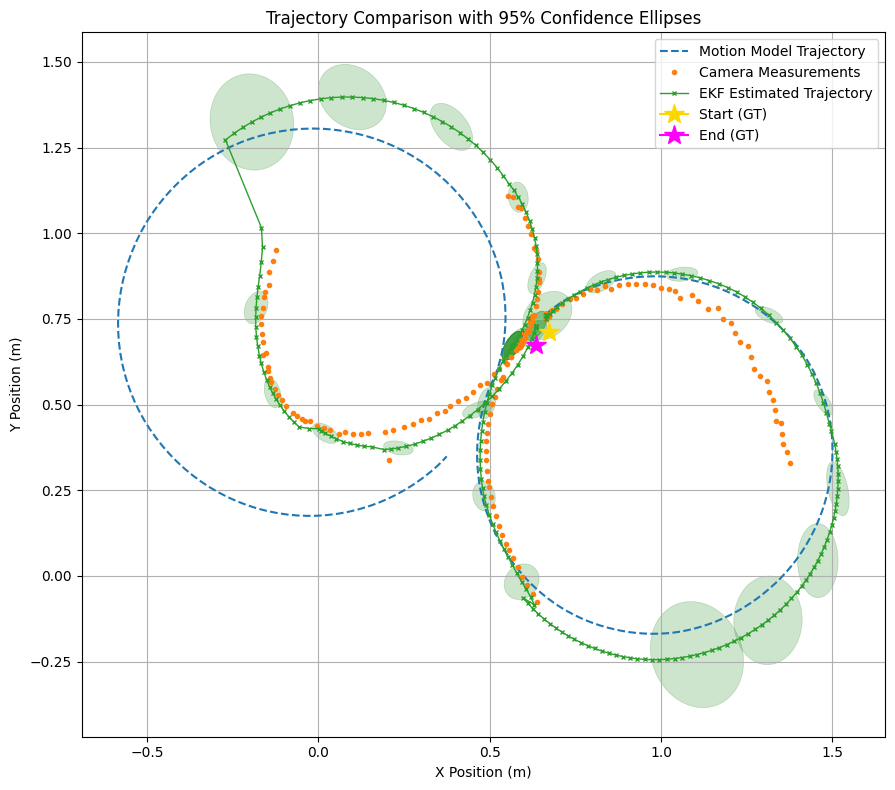

In [23]:
# Plot all trajectories with 95% confidence ellipses
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
ax.plot(x_model, y_model, label='Motion Model Trajectory', linestyle='--')
ax.plot(x_cam_list, y_cam_list, label='Camera Measurements', marker='o', markersize=3, linestyle='None')
ax.plot(x_ekf_list, y_ekf_list, label='EKF Estimated Trajectory', marker='x', markersize=3, linestyle='-', linewidth=1)

# Draw 95% confidence ellipses every N steps
# Skip until covariance position trace drops below a threshold (initial Sigma_0=I is too large)
N = 10
for i in range(0, len(cov_list), N):
    cov_xy = cov_list[i][0:2, 0:2]
    if np.trace(cov_xy) > 0.01:  # skip if position uncertainty > ~10cm
        continue
    eigvals, eigvecs = np.linalg.eigh(cov_xy)
    eigvals = np.maximum(eigvals, 0)
    # scale up for visibility
    scale = 5.991
    width = 2 * np.sqrt(scale * eigvals[0])
    height = 2 * np.sqrt(scale * eigvals[1])
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    ell = Ellipse(xy=(x_ekf_list[i], y_ekf_list[i]), width=width, height=height,
                  angle=angle, facecolor='green', edgecolor='darkgreen', alpha=0.2, linewidth=0.5)
    ax.add_patch(ell)

# Add ground truth start and end points
inches_to_meters = 0.0254
start_state = (28 * inches_to_meters, 26.5 * inches_to_meters, 45 * np.pi / 180) 
end_state = (26.5 * inches_to_meters, 25 * inches_to_meters, 69 * np.pi / 180) 
ax.plot(start_state[1], start_state[0], marker='*', color='gold', markersize=15, label='Start (GT)')
ax.plot(end_state[1], end_state[0], marker='*', color='magenta', markersize=15, label='End (GT)')


ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_title('Trajectory Comparison with 95% Confidence Ellipses')
ax.legend()
ax.set_aspect('equal')
ax.grid()
plt.tight_layout()
plt.show()

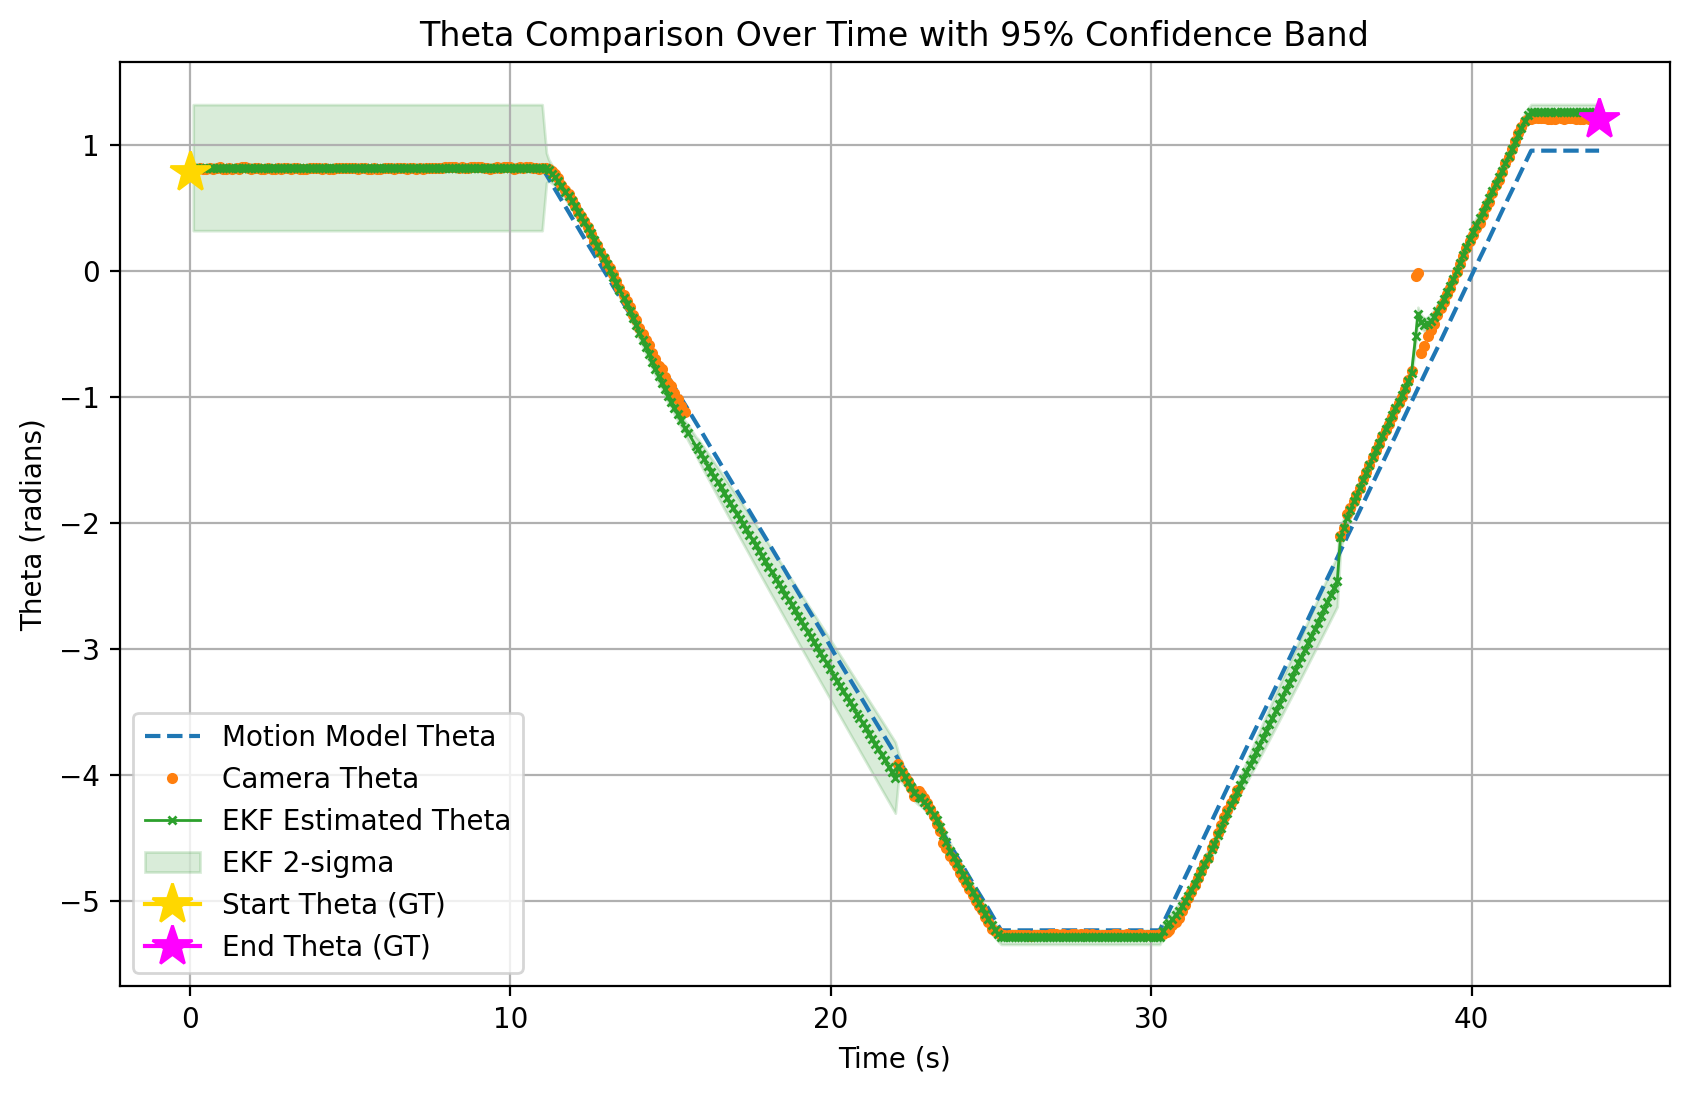

In [24]:
# Plot theta over time with +-2sigma confidence band
theta_cam_valid = [t for t in theta_cam_list if t is not None]
time_cam_valid = [time_list[i] for i, t in enumerate(theta_cam_list) if t is not None]
theta_cam_unwrapped_valid = np.unwrap(theta_cam_valid)

theta_ekf = np.array(theta_ekf_list)
# Clip sigma to exclude initial transient from Sigma_0 = I
sigma_theta = np.array([2 * np.sqrt(max(cov[2, 2], 0)) for cov in cov_list])
sigma_theta = np.minimum(sigma_theta, 0.5)  # cap at 0.5 rad for display
time_ekf = time_list[1:]

plt.figure(figsize=(10, 6), dpi=200)
plt.plot(time_list, theta_model, label='Motion Model Theta', linestyle='--')
plt.plot(time_cam_valid, theta_cam_unwrapped_valid, label='Camera Theta', marker='o', markersize=3, linestyle='None')
plt.plot(time_ekf, theta_ekf, label='EKF Estimated Theta', marker='x', markersize=3, linestyle='-', linewidth=1)
plt.fill_between(time_ekf, theta_ekf - sigma_theta, theta_ekf + sigma_theta,
                 color='green', alpha=0.15, label='EKF 2-sigma')

# Add ground truth start and end theta from start and end states
plt.plot(time_list[0], start_state[2], marker='*', color='gold', markersize=15, label='Start Theta (GT)')
plt.plot(time_list[-1], end_state[2], marker='*', color='magenta', markersize=15, label='End Theta (GT)')

plt.xlabel('Time (s)')
plt.ylabel('Theta (radians)')
plt.title('Theta Comparison Over Time with 95% Confidence Band')
plt.legend()
plt.grid()
plt.show()

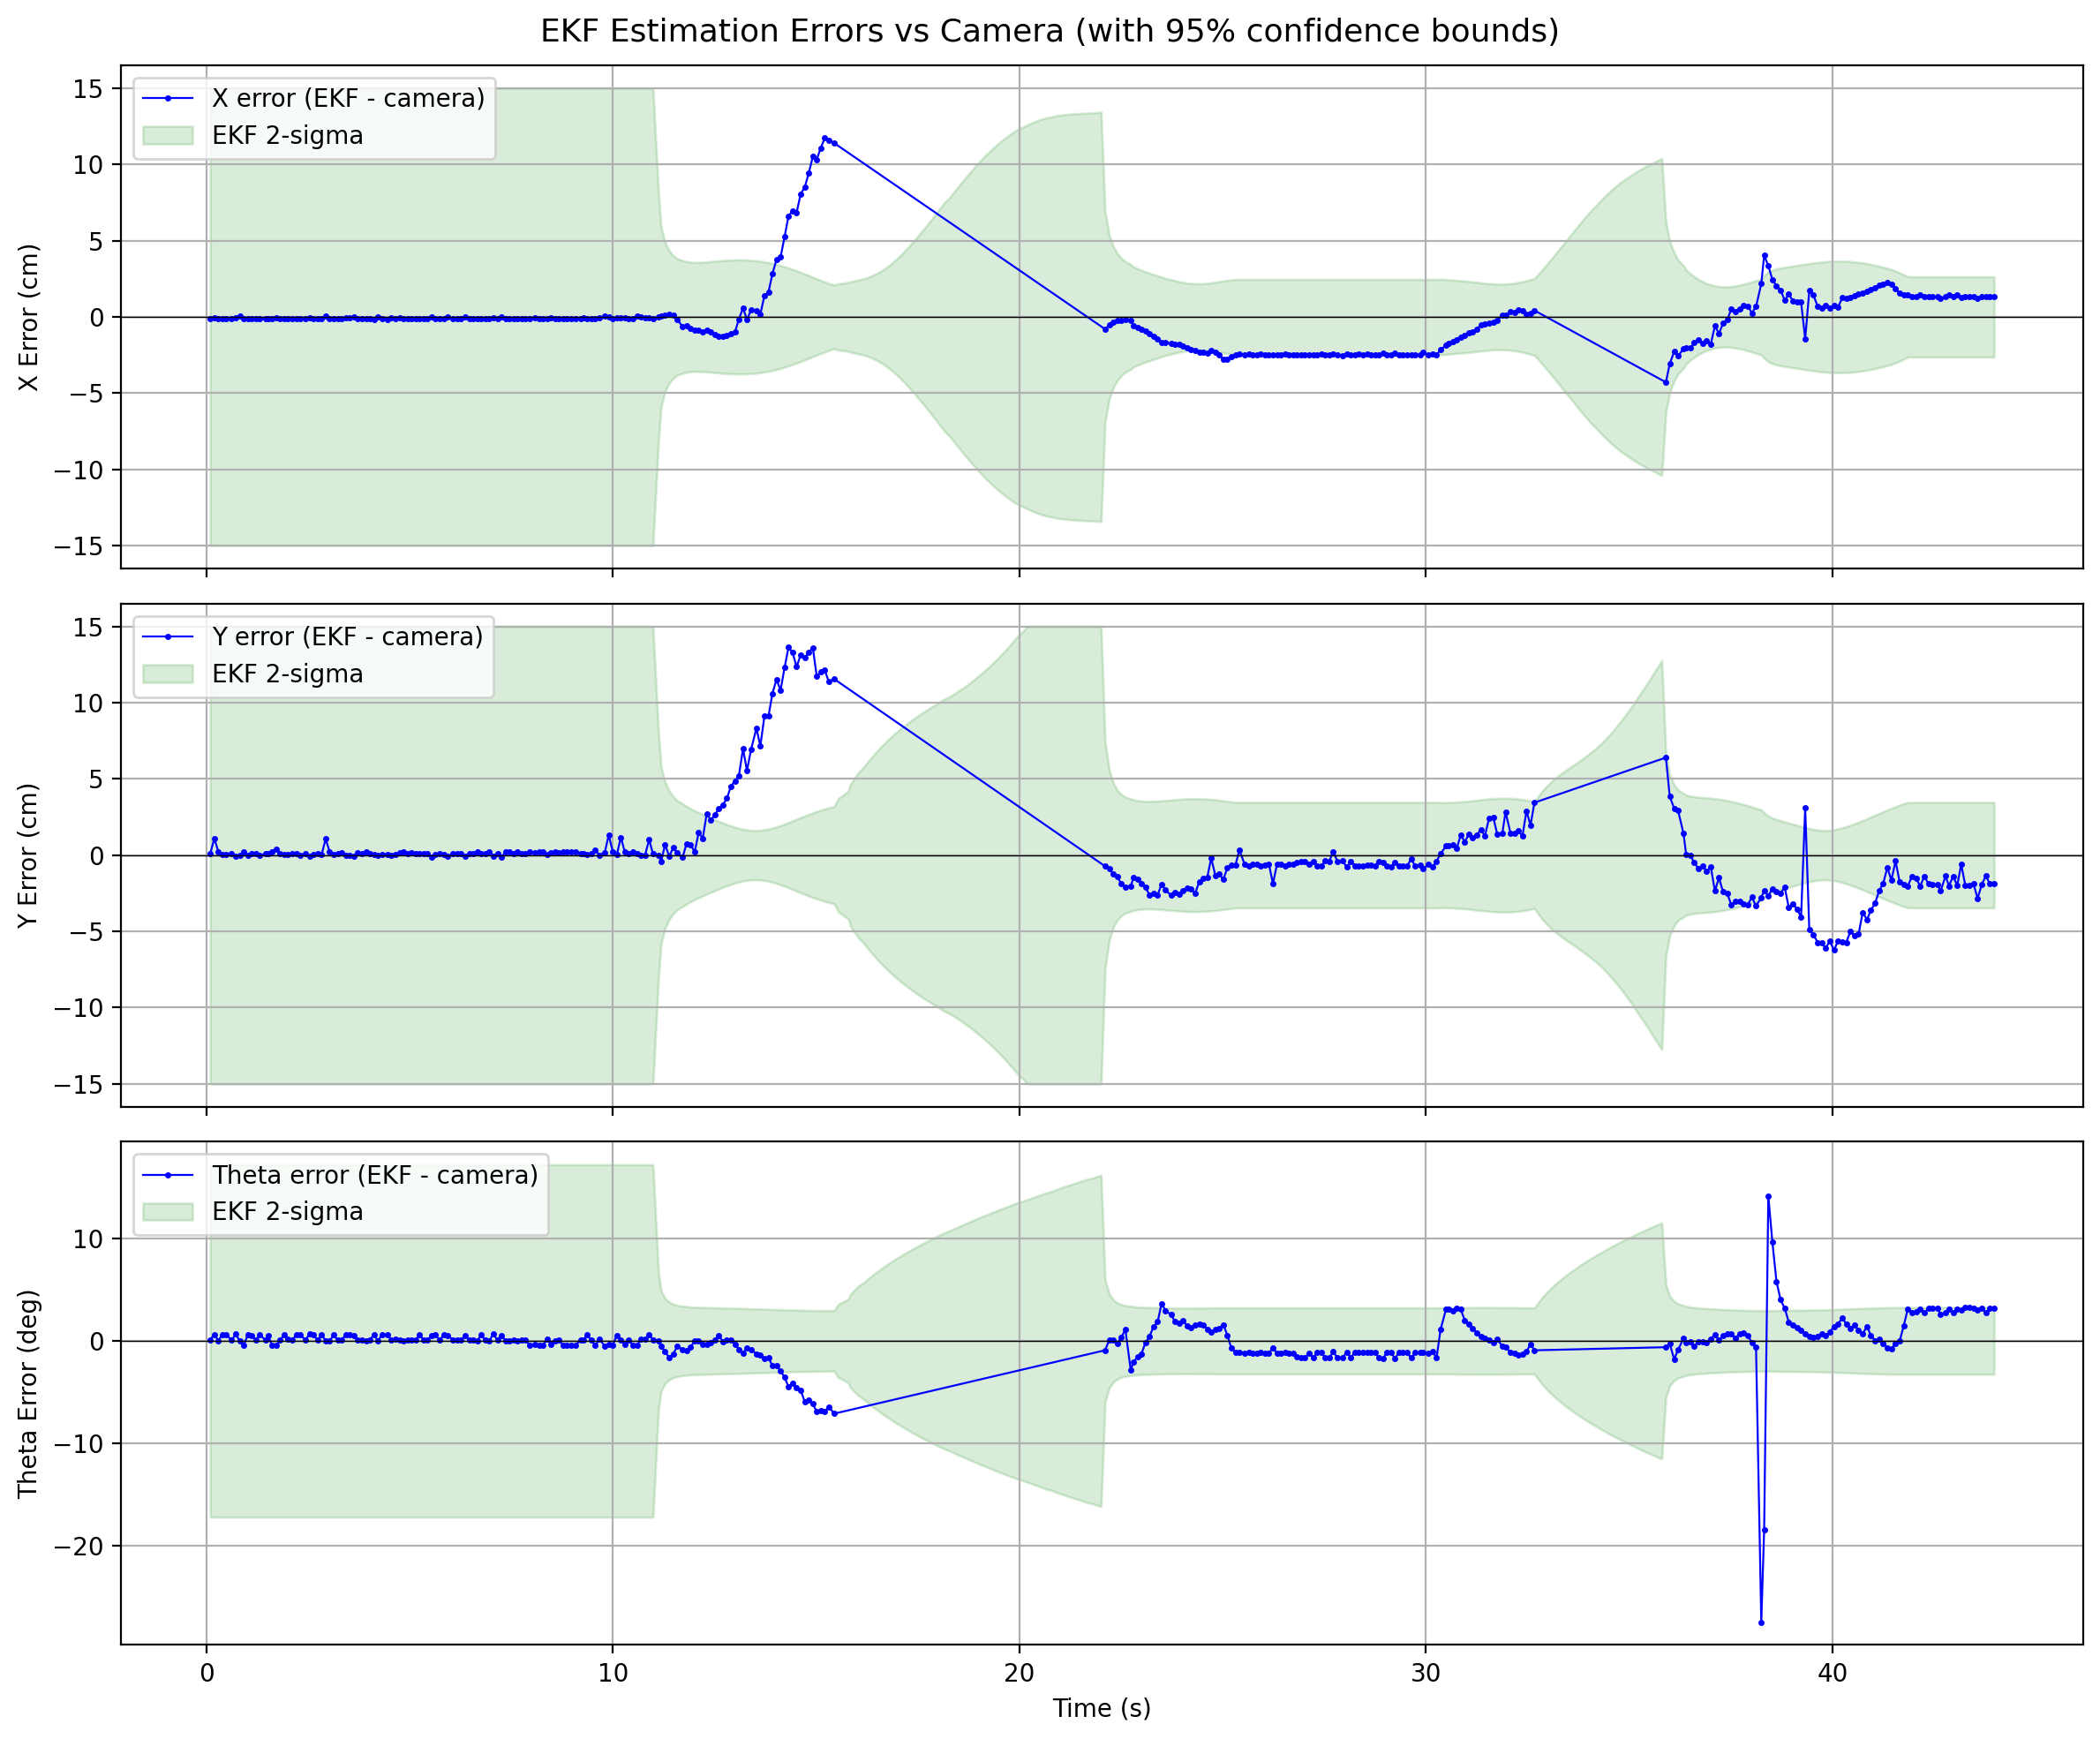

X  error:  mean=-0.05 cm,  RMSE=2.32 cm
Y  error:  mean=0.21 cm,  RMSE=3.43 cm
Theta error: mean=-0.08 deg, RMSE=2.66 deg


In [25]:
# Compute EKF errors relative to camera measurements with +-2sigma bounds
time_ekf = np.array(time_list[1:])
x_ekf = np.array(x_ekf_list)
y_ekf = np.array(y_ekf_list)
theta_ekf = np.array(theta_ekf_list)

# Extract +-2sigma bounds from EKF covariance, capped for display
sigma_x = np.minimum(np.array([2 * np.sqrt(max(cov[0, 0], 0)) for cov in cov_list]), 0.15)
sigma_y = np.minimum(np.array([2 * np.sqrt(max(cov[1, 1], 0)) for cov in cov_list]), 0.15)
sigma_theta = np.minimum(np.array([2 * np.sqrt(max(cov[2, 2], 0)) for cov in cov_list]), 0.3)

# Errors at camera-available timesteps
err_x, err_y, err_theta, err_time = [], [], [], []
for i in range(len(x_ekf)):
    cam_x = x_cam_list[i + 1]  # EKF list is offset by 1
    cam_y = y_cam_list[i + 1]
    cam_t = theta_cam_list[i + 1]
    if cam_x is not None:
        err_x.append(x_ekf[i] - cam_x)
        err_y.append(y_ekf[i] - cam_y)
        dt = theta_ekf[i] - cam_t
        dt = (dt + np.pi) % (2 * np.pi) - np.pi
        err_theta.append(dt)
        err_time.append(time_ekf[i])

err_x = np.array(err_x)
err_y = np.array(err_y)
err_theta = np.array(err_theta)
err_time = np.array(err_time)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, dpi=200)

# X error
axes[0].plot(err_time, err_x * 100, 'b.-', markersize=3, linewidth=0.8, label='X error (EKF - camera)')
axes[0].fill_between(time_ekf, -sigma_x * 100, sigma_x * 100, color='green', alpha=0.15, label='EKF 2-sigma')
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].set_ylabel('X Error (cm)')
axes[0].legend(loc='upper left')
axes[0].grid()

# Y error
axes[1].plot(err_time, err_y * 100, 'b.-', markersize=3, linewidth=0.8, label='Y error (EKF - camera)')
axes[1].fill_between(time_ekf, -sigma_y * 100, sigma_y * 100, color='green', alpha=0.15, label='EKF 2-sigma')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_ylabel('Y Error (cm)')
axes[1].legend(loc='upper left')
axes[1].grid()

# Theta error
axes[2].plot(err_time, np.degrees(err_theta), 'b.-', markersize=3, linewidth=0.8, label='Theta error (EKF - camera)')
axes[2].fill_between(time_ekf, -np.degrees(sigma_theta), np.degrees(sigma_theta),
                     color='green', alpha=0.15, label='EKF 2-sigma')
axes[2].axhline(0, color='k', linewidth=0.5)
axes[2].set_ylabel('Theta Error (deg)')
axes[2].set_xlabel('Time (s)')
axes[2].legend(loc='upper left')
axes[2].grid()

fig.suptitle('EKF Estimation Errors vs Camera (with 95% confidence bounds)', fontsize=13)
plt.tight_layout()
plt.show()

# Summary statistics
print(f"X  error:  mean={np.mean(err_x)*100:.2f} cm,  RMSE={np.sqrt(np.mean(err_x**2))*100:.2f} cm")
print(f"Y  error:  mean={np.mean(err_y)*100:.2f} cm,  RMSE={np.sqrt(np.mean(err_y**2))*100:.2f} cm")
print(f"Theta error: mean={np.mean(np.degrees(err_theta)):.2f} deg, RMSE={np.sqrt(np.mean(np.degrees(err_theta)**2)):.2f} deg")

In [26]:
import numpy as np
import math
from extended_kalman_filter import ExtendedKalmanFilter

# Run EKF again with diagnostics
x_0 = [x_cam_list[0], y_cam_list[0], theta_cam_list[0]]
Sigma_0 = np.eye(3)
encoder_counts_0 = encoder_count_list[0]
ekf_diag = ExtendedKalmanFilter(x_0, Sigma_0, encoder_counts_0)

corrected = 0
rejected = 0
skipped_stationary = 0
skipped_no_cam = 0

for t in range(1, len(encoder_count_list)):
    row = ekf_data[t]
    delta_t = ekf_data[t][0] - ekf_data[t-1][0]
    u_t = np.array([encoder_count_list[t], steering_angle_list[t]])
    cam = row[3]
    z_t = np.array(cam) if cam is not None else None
    
    encoder_change = abs(u_t[0] - ekf_diag.last_encoder_counts)
    
    if encoder_change < 1:
        skipped_stationary += 1
    elif z_t is None:
        skipped_no_cam += 1
    else:
        # Check if measurement will be accepted or rejected
        ekf_diag_copy_mean = list(ekf_diag.state_mean)
        # After prediction, check Mahalanobis
    
    ekf_diag.update(u_t, z_t, delta_t)

    if encoder_change >= 1 and z_t is not None:
        # Check if correction happened by comparing predicted vs actual
        H_t = np.eye(3)
        Q_t = ekf_diag.get_Q()
        z_pred = ekf_diag.get_h_function(ekf_diag.predicted_state_mean)
        y_t = z_t - z_pred
        y_t[2] = (y_t[2] + math.pi) % (2 * math.pi) - math.pi
        S_t = H_t @ ekf_diag.predicted_state_covariance @ H_t.T + Q_t
        d_sq = y_t.T @ np.linalg.inv(S_t) @ y_t
        if d_sq > 9.21:
            rejected += 1
        else:
            corrected += 1

print(f"=== EKF Performance Summary ===")
print(f"Total timesteps: {len(encoder_count_list) - 1}")
print(f"Stationary (skipped): {skipped_stationary}")
print(f"Moving, no camera: {skipped_no_cam}")
print(f"Moving, camera accepted: {corrected}")
print(f"Moving, camera rejected: {rejected}")
print(f"Correction rate: {corrected}/{corrected + rejected} = {100*corrected/(corrected+rejected):.1f}%")


=== EKF Performance Summary ===
Total timesteps: 435
Stationary (skipped): 179
Moving, no camera: 95
Moving, camera accepted: 142
Moving, camera rejected: 19
Correction rate: 142/161 = 88.2%


In [27]:
# Calculate metrics for the paper statement
import numpy as np

# 1. Steady-state positional RMSE (EKF vs camera when available)
position_rmse = np.sqrt(np.mean(err_x**2 + err_y**2))  # keep in meters

# 2. Initial pose error and convergence time
# Compare EKF trajectory vs camera at start
initial_x_err = abs(x_ekf_list[0] - x_cam_list[1])  # meters (EKF index 0 = camera index 1)
initial_y_err = abs(y_ekf_list[0] - y_cam_list[1])  # meters
initial_pos_err = np.sqrt(initial_x_err**2 + initial_y_err**2)

# Find convergence time: when position error drops below 2*RMSE consistently
convergence_threshold = 2 * position_rmse
position_errors = np.sqrt(err_x**2 + err_y**2)

# Find first time when error stays below threshold for at least 5 consecutive measurements
converged_idx = None
for i in range(len(position_errors) - 4):
    if all(position_errors[i:i+5] < convergence_threshold):
        converged_idx = i
        break

convergence_time = err_time[converged_idx] if converged_idx is not None else None

print("=== EKF Performance Metrics ===")
print(f"1. Steady-state positional RMSE: {position_rmse:.4f} m")
print(f"2. Initial pose error: {initial_pos_err:.4f} m") 
print(f"3. Convergence time: {convergence_time:.1f} seconds" if convergence_time else "3. Did not converge within threshold")

print(f"\nAdditional details:")
print(f"- X RMSE: {np.sqrt(np.mean(err_x**2)):.4f} m")  
print(f"- Y RMSE: {np.sqrt(np.mean(err_y**2)):.4f} m")
print(f"- Theta RMSE: {np.sqrt(np.mean(err_theta**2)):.4f} rad ({np.sqrt(np.mean(err_theta**2))*180/np.pi:.1f} degrees)")

=== EKF Performance Metrics ===
1. Steady-state positional RMSE: 0.0414 m
2. Initial pose error: 0.0016 m
3. Convergence time: 0.1 seconds

Additional details:
- X RMSE: 0.0232 m
- Y RMSE: 0.0343 m
- Theta RMSE: 0.0465 rad (2.7 degrees)
